# Tutorial 0: Inside model compression

*A hands-on look at what SNAC-Pack's local search does.*

Tutorials 1 and 2 treat pruning and quantization as a black box. Here we show how it actually works on a small MNIST classifier, using the same libraries SNAC-Pack uses
(`tensorflow_model_optimization` and QKeras).

| Section | Topic |
|---|---|
| A | A small network learning to read digits |
| B | Unstructured pruning and iterative magnitude pruning |
| C | Quantization: fixed-point rounding and QAT |
| D | How this maps onto the pipeline in Tutorial 1 |

In [1]:
!which python

/opt/miniconda3/envs/snac-pack-refactor/bin/python


In [ ]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent.parent          # repo root
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_model_optimization as tfmot
from qkeras import quantizers

from utils.tf_data_preprocessing import load_and_preprocess_mnist
from utils.tf_local_search_separated import convert_to_qat_model

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
tf.get_logger().setLevel('ERROR')
np.random.seed(0)
tf.random.set_seed(0)

# Tutorial-wide knobs. In SNAC-Pack these are in the YAML `local_search` block.
RESIZE          = 8                       # MNIST resized to 8x8 (matches Tutorial 1)
SUBSET          = 10000                   # samples used (keeps the notebook fast)
HIDDEN_WIDTH    = 64                      # one hidden layer
BASE_EPOCHS     = 8                       # FP32 training epochs
PRUNE_RATE      = 0.7                     # sparsity schedule base
PRUNE_ITERS     = 8                       # iterative-pruning steps
PRUNE_EPOCHS    = 3                       # fine-tune epochs per pruning step
QAT_EPOCHS      = 3                       # quantization-aware fine-tune epochs
PRECISION_PAIRS = [(16, 6), (4, 1), (3, 1)]   # ap_fixed<W, I> pairs to sweep

print('TensorFlow', tf.__version__)

## A. The Network

A neural network is a stack of layers, each doing `y = W x + b` followed by a
non-linearity. Training adjusts the weight matrices `W` so the network maps each image to
the right label.

Our task is MNIST (classify a digit 0-9). We resize each image to 8x8 = 64 pixels, as
Tutorial 1 does, and feed that vector into a small MLP.

Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (200, 8, 8, 1), x_val shape: (200, 8, 8, 1)
  y_train shape: (200,), y_val shape: (200,)


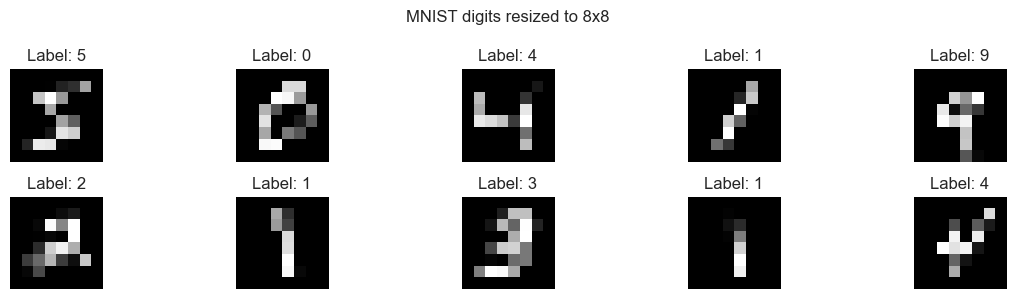

In [3]:
x_viz, y_viz, _, _ = load_and_preprocess_mnist(
    resize_val=RESIZE, subset_size=200, flatten=False, one_hot=False)

plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_viz[i].squeeze(), cmap='gray')
    plt.title(f'Label: {y_viz[i]}')
    plt.axis('off')
plt.suptitle(f'MNIST digits resized to {RESIZE}x{RESIZE}')
plt.tight_layout()
plt.show()

### Train the base model

```
input (64) -> Dense(64, relu) -> Dense(10, softmax) -> class probabilities
```

That is `64 x 64 = 4096` weights in the first layer and `64 x 10 = 640` in the second.
Every weight becomes a multiplier on the FPGA, which is why pruning and quantization
matter. We train once and reuse this `base_model` everywhere below.

Data loaded and preprocessed:
  Resize: 8x8
  x_train shape: (10000, 64), x_val shape: (10000, 64)
  y_train shape: (10000, 10), y_val shape: (10000, 10)
Model: "base_mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_0 (Dense)             (None, 64)                4160      
                                                                 
 dense_out (Dense)           (None, 10)                650       
                                                                 
Total params: 4810 (18.79 KB)
Trainable params: 4810 (18.79 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/8
79/79 - 0s - loss: 2.0408 - accuracy: 0.4207 - val_loss: 1.6546 - val_accuracy: 0.6652 - 271ms/epoch - 3ms/step
Epoch 2/8
79/79 - 0s - loss: 1.3132 - accuracy: 0.7260 - val_loss: 1.0234 - val_accuracy: 0.7667 - 70ms/epoch - 881us/step
Epoch 3/8
79/79 - 0s 

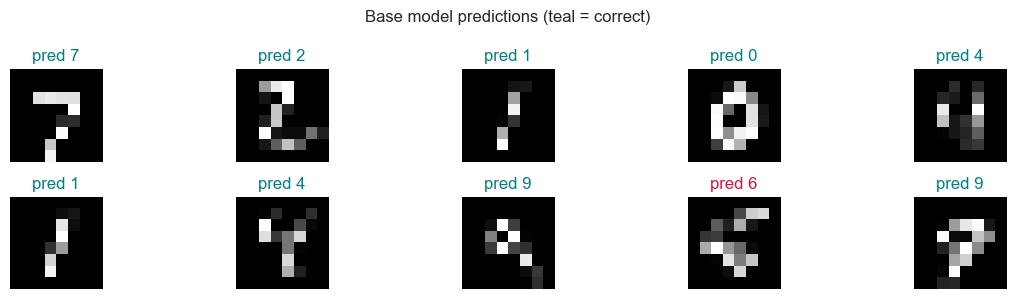

In [4]:
x_train, y_train, x_val, y_val = load_and_preprocess_mnist(
    resize_val=RESIZE, subset_size=SUBSET, flatten=True, one_hot=True)
INPUT_DIM = RESIZE * RESIZE

base_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,)),
    tf.keras.layers.Dense(HIDDEN_WIDTH, activation='relu', name='dense_0'),
    tf.keras.layers.Dense(10, activation='softmax', name='dense_out'),
], name='base_mlp')

base_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
base_model.summary()

base_model.fit(x_train, y_train, validation_data=(x_val, y_val),
               epochs=BASE_EPOCHS, batch_size=128, verbose=2)

_, base_acc = base_model.evaluate(x_val, y_val, verbose=0)
print(f'\nBaseline FP32 validation accuracy: {base_acc:.4f}')

# Show a handful of predictions.
probs = base_model.predict(x_val[:10], verbose=0)
preds, truth = probs.argmax(1), y_val[:10].argmax(1)
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_val[i].reshape(RESIZE, RESIZE), cmap='gray')
    ok = preds[i] == truth[i]
    plt.title(f'pred {preds[i]}', color='teal' if ok else 'crimson')
    plt.axis('off')
plt.suptitle('Base model predictions (teal = correct)')
plt.tight_layout()
plt.show()

### What a weight looks like

Each hidden neuron has 64 first-layer weights. Reshaped to 8x8, they show the pattern that
neuron responds to (red positive, blue negative). These are the numbers we now prune (set
to zero) and quantize (store with fewer bits).

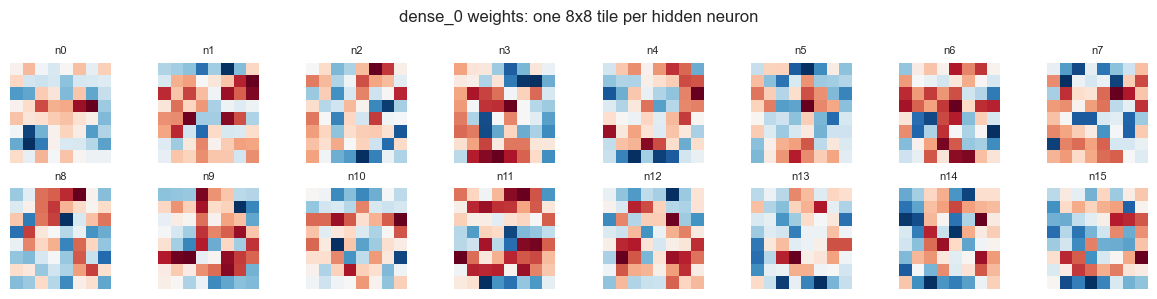

dense_0 kernel shape (64, 64) -> 4096 weights = 4096 multipliers in hardware


In [5]:
W0 = base_model.get_layer('dense_0').get_weights()[0]   # shape (64, 64)

plt.figure(figsize=(12, 3))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(W0[:, i].reshape(RESIZE, RESIZE), cmap='RdBu_r')
    plt.title(f'n{i}', fontsize=8)
    plt.axis('off')
plt.suptitle('dense_0 weights: one 8x8 tile per hidden neuron')
plt.tight_layout()
plt.show()

print(f'dense_0 kernel shape {W0.shape} -> {W0.size} weights = {W0.size} multipliers in hardware')

## B. Pruning

Trained networks are over-parameterized: most weights are small and barely matter.
Magnitude pruning ranks weights by `|w|` and zeroes the smallest fraction. Every zeroed
weight is one multiply hls4ml never builds.

<details>
<summary>Background: unstructured vs structured pruning</summary>

**Unstructured** pruning zeroes individual weights anywhere in the matrix. It reaches the
highest sparsity but leaves a sparse matrix, useful only on hardware that skips zeros.
hls4ml does this: it builds a multiplier only for each surviving weight.

**Structured** pruning removes whole neurons or filters, shrinking layer widths into a
smaller dense network that runs anywhere, at lower achievable sparsity.

SNAC-Pack uses unstructured magnitude pruning, shown here.
</details>

### Why one-shot pruning fails

Pruning the trained model once and stopping breaks quickly. Below we zero increasing
fractions of the smallest weights without retraining, and accuracy collapses once the
network loses weights it relied on.

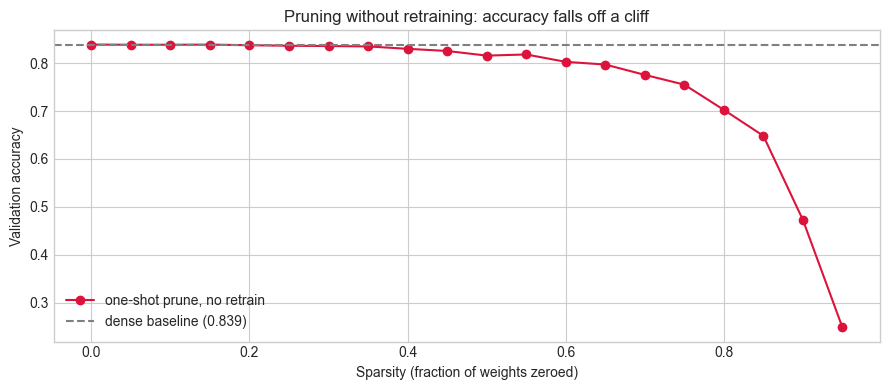

In [6]:
def prune_weights_by_magnitude(model, sparsity):
    """Copy of `model` with the smallest-|w| fraction of Dense kernel weights zeroed,
    using one global magnitude threshold."""
    clone = tf.keras.models.clone_model(model)
    clone.set_weights(model.get_weights())
    dense = [l for l in clone.layers if isinstance(l, tf.keras.layers.Dense)]
    all_kernel = np.concatenate([l.get_weights()[0].ravel() for l in dense])
    thresh = -1.0 if sparsity <= 0 else np.quantile(np.abs(all_kernel), sparsity)
    for l in dense:
        w = l.get_weights()
        w[0] = w[0] * (np.abs(w[0]) > thresh)
        l.set_weights(w)
    return clone

sparsities = np.linspace(0.0, 0.95, 20)
oneshot_acc = []
for s in sparsities:
    m = prune_weights_by_magnitude(base_model, s)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    oneshot_acc.append(m.evaluate(x_val, y_val, verbose=0)[1])

plt.figure(figsize=(9, 4))
plt.plot(sparsities, oneshot_acc, 'o-', color='crimson', label='one-shot prune, no retrain')
plt.axhline(base_acc, ls='--', color='gray', label=f'dense baseline ({base_acc:.3f})')
plt.xlabel('Sparsity (fraction of weights zeroed)')
plt.ylabel('Validation accuracy')
plt.title('Pruning without retraining: accuracy falls off a cliff')
plt.legend(); plt.tight_layout(); plt.show()

### Iterative magnitude pruning (IMP)

The fix is to prune gradually and retrain after each step. SNAC-Pack raises the target
sparsity on a schedule

$$\text{sparsity}_i = 1 - r^{\,i+1}$$

with rate `r = 0.7`: 30%, 51%, 66%, up to ~94% by step 8. It also uses lottery-ticket
rewinding: keep the mask, but reset the surviving weights to their original trained values
before the next round. The cell below reimplements `run_pruning_only_loop` from
`utils/tf_local_search_separated.py` with the same `tfmot` calls.

  iter 1/8   target sparsity 0.300   accuracy 0.8441
  iter 2/8   target sparsity 0.510   accuracy 0.8364
  iter 3/8   target sparsity 0.657   accuracy 0.8227
  iter 4/8   target sparsity 0.760   accuracy 0.8017
  iter 5/8   target sparsity 0.832   accuracy 0.7575
  iter 6/8   target sparsity 0.882   accuracy 0.6604
  iter 7/8   target sparsity 0.918   accuracy 0.5885
  iter 8/8   target sparsity 0.942   accuracy 0.4791


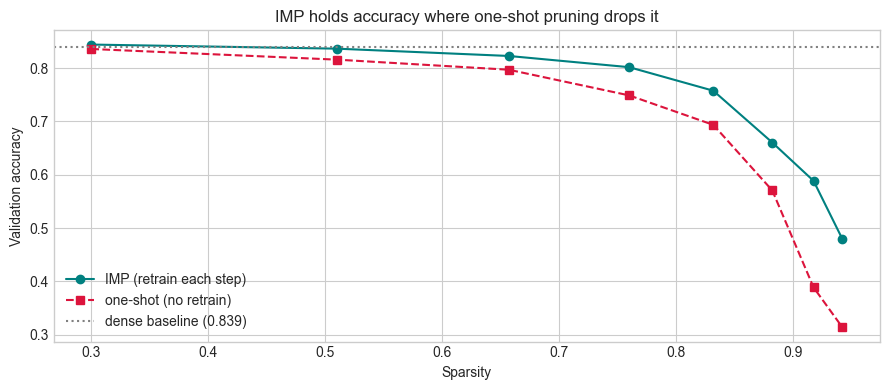

In [7]:
def iterative_magnitude_pruning(model, n_iters, rate, epochs_per_iter):
    records = []
    model_to_prune = tf.keras.models.clone_model(model)
    model_to_prune.set_weights(model.get_weights())
    original_weights = model_to_prune.get_weights()       # lottery-ticket checkpoint

    for i in range(n_iters):
        target_sparsity = 1 - rate ** (i + 1)             # SNAC-Pack schedule
        params = {'pruning_schedule': tfmot.sparsity.keras.ConstantSparsity(target_sparsity, 0, 100)}
        pruned = tfmot.sparsity.keras.prune_low_magnitude(model_to_prune, **params)
        pruned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        pruned.fit(x_train, y_train, validation_data=(x_val, y_val),
                   epochs=epochs_per_iter, batch_size=128,
                   callbacks=[tfmot.sparsity.keras.UpdatePruningStep()], verbose=0)

        stripped = tfmot.sparsity.keras.strip_pruning(pruned)
        stripped.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        acc = stripped.evaluate(x_val, y_val, verbose=0)[1]
        records.append({'iteration': i + 1, 'sparsity': target_sparsity, 'accuracy': acc})
        print(f'  iter {i + 1}/{n_iters}   target sparsity {target_sparsity:.3f}   accuracy {acc:.4f}')

        # Lottery-ticket rewind: keep the mask, restore the original weight values.
        rewound = [o * np.where(c != 0, 1.0, 0.0)
                   for o, c in zip(original_weights, stripped.get_weights())]
        model_to_prune.set_weights(rewound)

    return pd.DataFrame(records)

imp_df = iterative_magnitude_pruning(base_model, PRUNE_ITERS, PRUNE_RATE, PRUNE_EPOCHS)

# One-shot pruning (no retrain) at the same sparsity targets, for comparison.
oneshot_at_targets = []
for s in imp_df['sparsity']:
    m = prune_weights_by_magnitude(base_model, s)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    oneshot_at_targets.append(m.evaluate(x_val, y_val, verbose=0)[1])

plt.figure(figsize=(9, 4))
plt.plot(imp_df['sparsity'], imp_df['accuracy'], 'o-', color='teal', label='IMP (retrain each step)')
plt.plot(imp_df['sparsity'], oneshot_at_targets, 's--', color='crimson', label='one-shot (no retrain)')
plt.axhline(base_acc, ls=':', color='gray', label=f'dense baseline ({base_acc:.3f})')
plt.xlabel('Sparsity'); plt.ylabel('Validation accuracy')
plt.title('IMP holds accuracy where one-shot pruning drops it')
plt.legend(); plt.tight_layout(); plt.show()

### Watch the matrix go sparse

Drag the slider to prune more of `dense_0`. Pruning is monotonic, so raising the slider
only zeros more cells (white). The count is the multipliers hls4ml would build.

In [11]:
_W0   = base_model.get_layer('dense_0').get_weights()[0]   # (64, 64)
_mag  = np.abs(_W0)
_rank = np.empty(_W0.size, dtype=int)
_rank[np.argsort(_mag, axis=None)] = np.arange(_W0.size)    # 0 = smallest |w|, pruned first
_rank = _rank.reshape(_W0.shape)

_cmap = plt.cm.viridis_r.copy()
_cmap.set_bad('white')

def _show_pruning(sparsity_pct):
    sparsity = sparsity_pct / 100.0
    n_pruned = int(round(sparsity * _W0.size))
    mask     = _rank >= n_pruned          # True = weight kept
    n_active = int(mask.sum())

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    im0 = ax[0].imshow(_mag, cmap='viridis_r', aspect='auto')
    ax[0].set_title(f'dense_0 |weights|   (all {_W0.size} active)')
    ax[0].set_xlabel('hidden neuron'); ax[0].set_ylabel('input pixel')
    fig.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(np.where(mask, _mag, np.nan), cmap=_cmap, aspect='auto')
    ax[1].set_title(f'pruned: {n_active} active / {_W0.size}   ({sparsity * 100:.0f}% sparse)')
    ax[1].set_xlabel('hidden neuron'); ax[1].set_ylabel('input pixel')
    fig.colorbar(im1, ax=ax[1], fraction=0.046)
    plt.tight_layout(); plt.show()
    print(f'{n_active} surviving weights (dense model: {_W0.size})')

try:
    import ipywidgets as widgets
    widgets.interact(
        _show_pruning,
        sparsity_pct=widgets.IntSlider(min=0, max=95, step=5, value=70,
                                       description='Sparsity %:',
                                       style={'description_width': 'initial'}),
    )
except ImportError:
    _show_pruning(70)

interactive(children=(IntSlider(value=70, description='Sparsity %:', max=95, step=5, style=SliderStyle(descrip…

In SNAC-Pack this is `run_pruning_only_loop` in
`utils/tf_local_search_separated.py` (combined QAT+prune in `tf_local_search_combined.py`).

## C. Quantization

Training uses 32-bit floats; FPGAs prefer fixed-point numbers written `ap_fixed<W, I>`:
`W` total bits, `I` integer bits, `W - I - 1` fractional bits, one sign bit. Fewer bits
mean smaller multipliers and less memory, at the cost of rounding error. Below we quantize
the real `dense_0` weights with QKeras `quantized_bits`, the quantizer SNAC-Pack uses.

In [9]:
flat_w = base_model.get_layer('dense_0').get_weights()[0].ravel().astype('float32')

def _show_quant(total_bits, int_bits):
    int_bits = min(int_bits, total_bits - 1)              # keep at least a sign bit
    q  = quantizers.quantized_bits(total_bits, int_bits, alpha=1)
    qw = q(flat_w).numpy()
    err  = np.abs(qw - flat_w)
    step = 2.0 ** (int_bits + 1 - total_bits)             # fixed-point resolution
    print(f'ap_fixed<{total_bits},{int_bits}>   step={step:.2e}   '
          f'mean|err|={err.mean():.2e}   max|err|={err.max():.2e}   '
          f'distinct levels used={np.unique(qw).size}')

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].hist(flat_w, bins=60, alpha=0.6, color='gray', label='FP32')
    ax[0].hist(qw,     bins=60, alpha=0.6, color='teal', label=f'<{total_bits},{int_bits}>')
    ax[0].set_title('Weight distribution'); ax[0].set_xlabel('value'); ax[0].legend()

    lim = np.abs(flat_w).max() * 1.05
    ax[1].plot(flat_w, qw, '.', ms=2, color='teal')
    ax[1].plot([-lim, lim], [-lim, lim], '--', color='gray')
    ax[1].set_title('FP32 vs quantized (staircase = rounding)')
    ax[1].set_xlabel('FP32 weight'); ax[1].set_ylabel('quantized weight')
    plt.tight_layout(); plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        _show_quant,
        total_bits=widgets.IntSlider(min=2, max=16, step=1, value=8,
                                     description='Total bits W:',
                                     style={'description_width': 'initial'}),
        int_bits=widgets.IntSlider(min=0, max=6, step=1, value=2,
                                   description='Int bits I:',
                                   style={'description_width': 'initial'}),
    )
except ImportError:
    _show_quant(8, 2)

interactive(children=(IntSlider(value=8, description='Total bits W:', max=16, min=2, style=SliderStyle(descrip…

### Post-training quantization vs QAT

Convert the trained weights to low precision and stop, and accuracy drops once rounding
error grows (post-training quantization, PTQ). Quantization-aware training (QAT) simulates
the rounding during training, so the network learns weights that survive it. Both paths
below build the QKeras model with `convert_to_qat_model`; only QAT fine-tunes after.

  <16,6>   PTQ 0.8388   QAT 0.8407


   <4,1>   PTQ 0.8013   QAT 0.8287


/opt/miniconda3/envs/snac-pack-refactor/lib/python3.10/site-packages/keras/src/initializers/initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


   <3,1>   PTQ 0.7491   QAT 0.8011


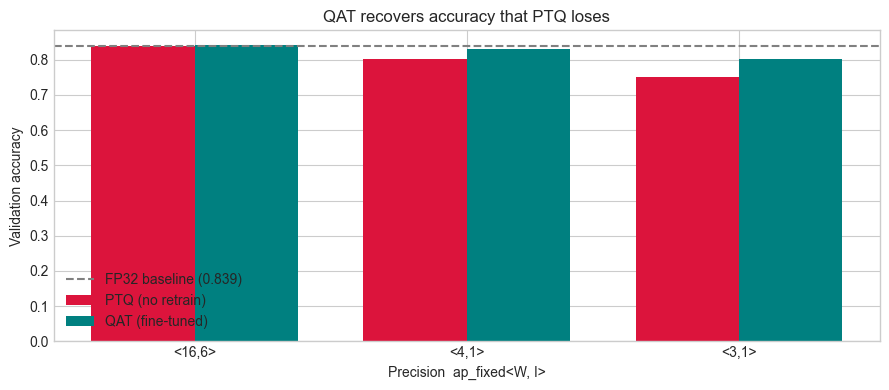

In [10]:
ptq_acc, qat_acc, labels = [], [], []
for (W, I) in PRECISION_PAIRS:
    labels.append(f'<{W},{I}>')

    # Post-training quantization: quantize the weights, no retraining.
    ptq = convert_to_qat_model(base_model, W, I)
    ptq.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    a_ptq = ptq.evaluate(x_val, y_val, verbose=0)[1]
    ptq_acc.append(a_ptq)

    # QAT: same conversion, then a short fine-tune (low LR, as in run_qat_only_loop).
    qat = convert_to_qat_model(base_model, W, I)
    qat.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
                loss='categorical_crossentropy', metrics=['accuracy'])
    qat.fit(x_train, y_train, validation_data=(x_val, y_val),
            epochs=QAT_EPOCHS, batch_size=128, verbose=0)
    a_qat = qat.evaluate(x_val, y_val, verbose=0)[1]
    qat_acc.append(a_qat)
    print(f'{labels[-1]:>8}   PTQ {a_ptq:.4f}   QAT {a_qat:.4f}')

x = np.arange(len(labels)); bw = 0.38
plt.figure(figsize=(9, 4))
plt.bar(x - bw / 2, ptq_acc, bw, color='crimson', label='PTQ (no retrain)')
plt.bar(x + bw / 2, qat_acc, bw, color='teal',    label='QAT (fine-tuned)')
plt.axhline(base_acc, ls='--', color='gray', label=f'FP32 baseline ({base_acc:.3f})')
plt.xticks(x, labels)
plt.xlabel('Precision  ap_fixed<W, I>'); plt.ylabel('Validation accuracy')
plt.title('QAT recovers accuracy that PTQ loses')
plt.legend(); plt.tight_layout(); plt.show()

In SNAC-Pack, `convert_to_qat_model` and `run_qat_only_loop` in
`utils/tf_local_search_separated.py` sweep these `precision_pairs` automatically.

## D. Where this lives in SNAC-Pack


You just did by hand what local search does automatically:

| You did | SNAC-Pack does |
|---|---|
| Trained a dense FP32 MLP | Takes the architecture from global search |
| IMP with rewinding | `run_pruning_only_loop` / combined loop |
| Swept `ap_fixed<W,I>` with QAT | `convert_to_qat_model` + `run_qat_only_loop` |
| Set knobs inline | Reads the YAML `local_search` block |

In Tutorial 1 these stages run end to end on MNIST, driven by one YAML file.